#Mount Drive, Import Libraries, Import Models

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_preprocess
from tensorflow.keras.applications.resnet50 import preprocess_input as res_preprocess
from tensorflow.keras.applications.densenet import preprocess_input as dense_preprocess
from tensorflow.keras.preprocessing import image as keras_image

BASE    = '/content/drive/MyDrive/SCHOOLFILES/CPE32/CPE313/final project/Freshwater Fish Disease Aquaculture in south asia'
CLS_DIR = BASE + '/Models_Fish_Classification'
DIS_DIR = BASE + '/Models_Disease_Classification'

# Species models
print('Loading species models...')
eff_species   = load_model(f'{CLS_DIR}/FishClass_EfficientNet_98.keras')
res_species   = load_model(f'{CLS_DIR}/FishClass_ResNet50_99.keras')
dense_species = load_model(f'{CLS_DIR}/FishClass_DenseNet121_96.keras')
print('Species models loaded.')

# Disease models
print('Loading disease models...')
eff_disease   = load_model(f'{DIS_DIR}/fish_disease_EfficientNetB0_finetuned.keras')
res_disease   = load_model(f'{DIS_DIR}/fish_disease_resnet50_finetuned.keras')
dense_disease = load_model(f'{DIS_DIR}/DenseNet121_FishDisease_finetuned_93.keras')
print('Disease models loaded.')

# Class names
species_classes = ['MilkFish', 'Tilapia']
disease_classes = [
    'Bacterial Red disease',
    'Bacterial gill disease',
    'Fungal diseases Saprolegniasis',
    'Healthy'
]

# Preprocessing map
preprocess_map = {
    'efficientnet': eff_preprocess,
    'resnet':       res_preprocess,
    'densenet':     dense_preprocess,
}

print('\nAll models ready.')

Loading species models...
Species models loaded.
Loading disease models...
Disease models loaded.

All models ready.


#  Pipeline Function & Pipeline Definitions

In [3]:
def run_pipeline(img_array, species_model, disease_model,
                 species_backbone, disease_backbone):
    """
    Runs a two-stage sequential pipeline on a single image.

    Parameters
    ----------
    img_array        : np.ndarray, shape (1, 224, 224, 3), raw pixel values (0-255)
    species_model    : Stage 1 Keras model
    disease_model    : Stage 2 Keras model
    species_backbone : str — 'efficientnet' | 'resnet' | 'densenet'
    disease_backbone : str — 'efficientnet' | 'resnet' | 'densenet'

    Returns
    -------
    dict with species prediction, disease prediction, and confidence scores
    """
    # Stage 1: Identify species
    img_s        = preprocess_map[species_backbone](img_array.copy())
    species_pred = species_model.predict(img_s, verbose=0)
    species_idx  = np.argmax(species_pred)
    species_conf = float(np.max(species_pred))

    # Stage 2: Diagnose disease
    img_d        = preprocess_map[disease_backbone](img_array.copy())
    disease_pred = disease_model.predict(img_d, verbose=0)
    disease_idx  = np.argmax(disease_pred)
    disease_conf = float(np.max(disease_pred))

    return {
        'species':      species_classes[species_idx],
        'species_conf': species_conf,
        'disease':      disease_classes[disease_idx],
        'disease_conf': disease_conf,
        'joint_conf':   species_conf * disease_conf,
    }


# Pipeline definitions
# Each entry: (display name, species_model, disease_model, species_backbone, disease_backbone)
pipelines = [
    ('EfficientNet → ResNet',   eff_species,   res_disease,   'efficientnet', 'resnet'),
    ('EfficientNet → DenseNet', eff_species,   dense_disease, 'efficientnet', 'densenet'),
    ('ResNet → EfficientNet',   res_species,   eff_disease,   'resnet',       'efficientnet'),
    ('ResNet → DenseNet',       res_species,   dense_disease, 'resnet',       'densenet'),
    ('DenseNet → EfficientNet', dense_species, eff_disease,   'densenet',     'efficientnet'),
    ('DenseNet → ResNet',       dense_species, res_disease,   'densenet',     'resnet'),
]

print(f'{len(pipelines)} pipelines defined.')

6 pipelines defined.


# Batch Evaluation Function

In [4]:
def evaluate_pipeline_on_dataset(species_model, disease_model,
                                  species_backbone, disease_backbone,
                                  val_data):
    """
    Evaluates a pipeline on the full validation dataset.

    Parameters
    ----------
    val_data : tf.data.Dataset
        Must yield (raw_images, disease_one_hot_labels).
        Images must be RAW (0-255), not preprocessed.

    Returns
    -------
    report         : dict  — sklearn classification report
    cm             : array — confusion matrix
    species_preds  : list  — Stage 1 predicted class indices
    disease_preds  : list  — Stage 2 predicted class indices
    disease_true   : list  — ground truth disease class indices
    species_confs  : list  — Stage 1 confidence scores
    disease_confs  : list  — Stage 2 confidence scores
    joint_confs    : list  — product of both confidence scores
    disease_probs  : array — Stage 2 full softmax probability vectors (N x n_classes)
    """
    all_species_preds = []
    all_disease_preds = []
    all_disease_true  = []
    all_species_confs = []
    all_disease_confs = []
    all_joint_confs   = []
    all_disease_probs = []   # ← NEW: full softmax vectors

    for images, labels in val_data:
        for i in range(len(images)):
            img = images[i].numpy()
            img = np.expand_dims(img, axis=0)  # (1, 224, 224, 3)

            # Stage 1: Species
            img_s = preprocess_map[species_backbone](img.copy())
            sp    = species_model.predict(img_s, verbose=0)
            all_species_preds.append(int(np.argmax(sp)))
            all_species_confs.append(float(np.max(sp)))

            # Stage 2: Disease
            img_d = preprocess_map[disease_backbone](img.copy())
            dp    = disease_model.predict(img_d, verbose=0)
            all_disease_preds.append(int(np.argmax(dp)))
            all_disease_confs.append(float(np.max(dp)))
            all_disease_probs.append(dp[0].tolist())   # ← store full softmax vector

            all_joint_confs.append(float(np.max(sp)) * float(np.max(dp)))

        all_disease_true.extend(np.argmax(labels.numpy(), axis=1).tolist())

    all_disease_preds = np.array(all_disease_preds)
    all_disease_true  = np.array(all_disease_true)
    all_disease_probs = np.array(all_disease_probs)   # shape: (N, n_classes)

    report = classification_report(
        all_disease_true, all_disease_preds,
        target_names=disease_classes,
        output_dict=True,
        zero_division=0
    )
    cm = confusion_matrix(all_disease_true, all_disease_preds)

    return (report, cm,
            all_species_preds, all_disease_preds, all_disease_true,
            all_species_confs, all_disease_confs, all_joint_confs,
            all_disease_probs)   # ← 9th return value

print('Evaluation function ready.')


Evaluation function ready.


In [5]:
from sklearn.metrics import accuracy_score

def get_species_accuracy(species_model, backbone, species_data):
    """Runs only the species model on the FreshWaterFishClasses dataset."""
    all_preds = []
    all_true = []

    for images, labels in species_data:
        for i in range(len(images)):
            img = images[i].numpy()
            img = np.expand_dims(img, axis=0)

            # Preprocess and predict
            img_s = preprocess_map[backbone](img.copy())
            sp = species_model.predict(img_s, verbose=0)

            all_preds.append(int(np.argmax(sp)))

        # Get true labels from the batch
        all_true.extend(np.argmax(labels.numpy(), axis=1).tolist())

    return accuracy_score(all_true, all_preds)

# Individual Model Evaluation - Fish Species Classification

In [6]:
# ── Individual Species Model Evaluation ─────────────────────────────────────
# Loads the species test set and evaluates each species model independently.

species_models = [
    ('EfficientNet', eff_species,   'efficientnet'),
    ('ResNet50',     res_species,   'resnet'),
    ('DenseNet121',  dense_species, 'densenet'),
]

val_species_data_eval = tf.keras.utils.image_dataset_from_directory(
    "/content/drive/MyDrive/SCHOOLFILES/CPE32/CPE313/final project/Freshwater Fish Disease Aquaculture in south asia/FreshWaterFishClasses/Test",
    image_size=(224, 224),
    batch_size=32,
    label_mode='categorical',
    shuffle=False
)
species_class_names = val_species_data_eval.class_names
print('Species classes:', species_class_names)

species_eval_results = []
species_eval_outputs = {}

for model_name, model, backbone in species_models:
    print(f'\nEvaluating {model_name} on species classification...')
    all_preds = []
    all_true  = []
    all_confs = []

    for images, labels in val_species_data_eval:
        for i in range(len(images)):
            img = images[i].numpy()
            img = np.expand_dims(img, axis=0)
            img_p = preprocess_map[backbone](img.copy())
            pred  = model.predict(img_p, verbose=0)
            all_preds.append(int(np.argmax(pred)))
            all_confs.append(float(np.max(pred)))
        all_true.extend(np.argmax(labels.numpy(), axis=1).tolist())

    all_preds = np.array(all_preds)
    all_true  = np.array(all_true)

    report = classification_report(
        all_true, all_preds,
        target_names=species_class_names,
        output_dict=True,
        zero_division=0
    )
    cm = confusion_matrix(all_true, all_preds)

    species_eval_outputs[model_name] = {
        'report':  report,
        'cm':      cm,
        'preds':   all_preds,
        'true':    all_true,
        'confs':   all_confs,
    }

    species_eval_results.append({
        'Model':           model_name,
        'Accuracy':        round(report['accuracy'], 4),
        'Macro F1':        round(report['macro avg']['f1-score'], 4),
        'Macro Precision': round(report['macro avg']['precision'], 4),
        'Macro Recall':    round(report['macro avg']['recall'], 4),
        'Mean Confidence': round(float(np.mean(all_confs)), 4),
    })
    print(f'  Accuracy: {report["accuracy"]:.4f} | Macro F1: {report["macro avg"]["f1-score"]:.4f}')

species_eval_df = pd.DataFrame(species_eval_results).sort_values('Accuracy', ascending=False).reset_index(drop=True)
print('\n=== Individual Species Model Comparison ===')
species_eval_df


Found 72 files belonging to 2 classes.
Species classes: ['MilkFish', 'Tilapia']

Evaluating EfficientNet on species classification...
  Accuracy: 0.9861 | Macro F1: 0.9861

Evaluating ResNet50 on species classification...
  Accuracy: 0.9861 | Macro F1: 0.9861

Evaluating DenseNet121 on species classification...
  Accuracy: 0.9583 | Macro F1: 0.9583

=== Individual Species Model Comparison ===


,Model,Accuracy,Macro F1,Macro Precision,Macro Recall,Mean Confidence
0,EfficientNet,0.9861,0.9861,0.9868,0.9857,0.9574
1,ResNet50,0.9861,0.9861,0.9868,0.9857,0.9570
2,DenseNet121,0.9583,0.9583,0.9583,0.9587,0.9210



--- EfficientNet ---
              precision    recall  f1-score   support

    MilkFish     1.0000    0.9714    0.9855        35
     Tilapia     0.9737    1.0000    0.9867        37

    accuracy                         0.9861        72
   macro avg     0.9868    0.9857    0.9861        72
weighted avg     0.9865    0.9861    0.9861        72


--- ResNet50 ---
              precision    recall  f1-score   support

    MilkFish     1.0000    0.9714    0.9855        35
     Tilapia     0.9737    1.0000    0.9867        37

    accuracy                         0.9861        72
   macro avg     0.9868    0.9857    0.9861        72
weighted avg     0.9865    0.9861    0.9861        72


--- DenseNet121 ---
              precision    recall  f1-score   support

    MilkFish     0.9444    0.9714    0.9577        35
     Tilapia     0.9722    0.9459    0.9589        37

    accuracy                         0.9583        72
   macro avg     0.9583    0.9587    0.9583        72
weighted avg 

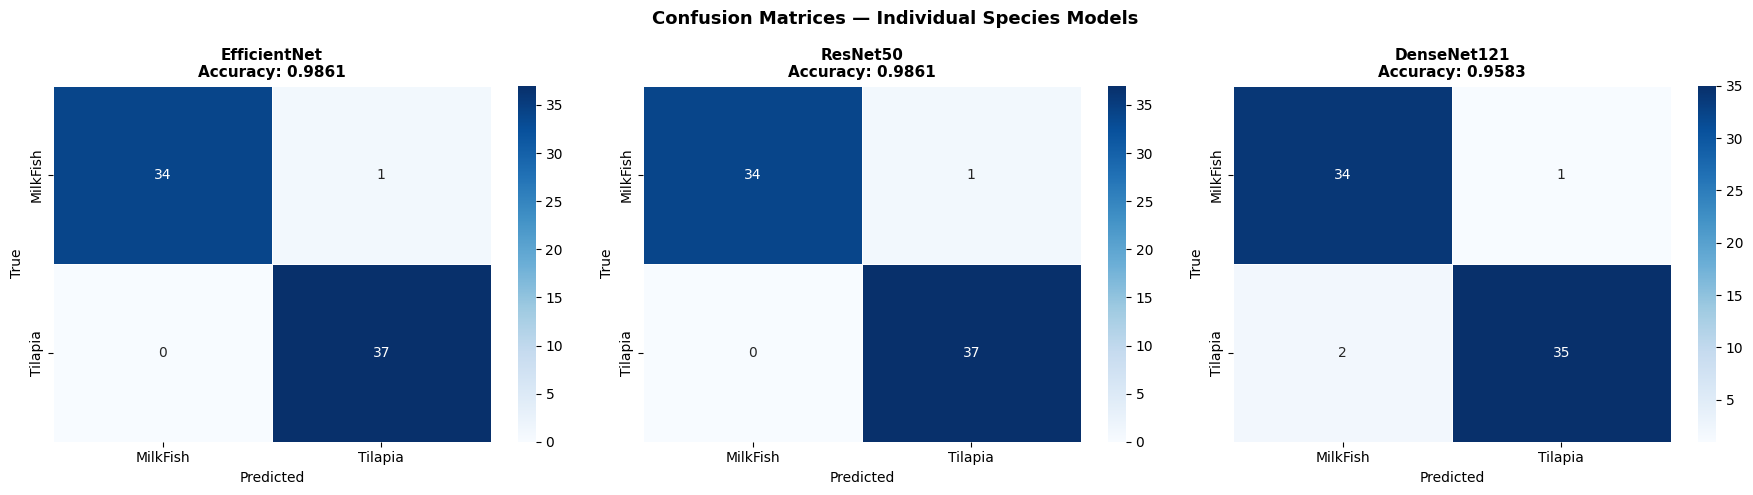

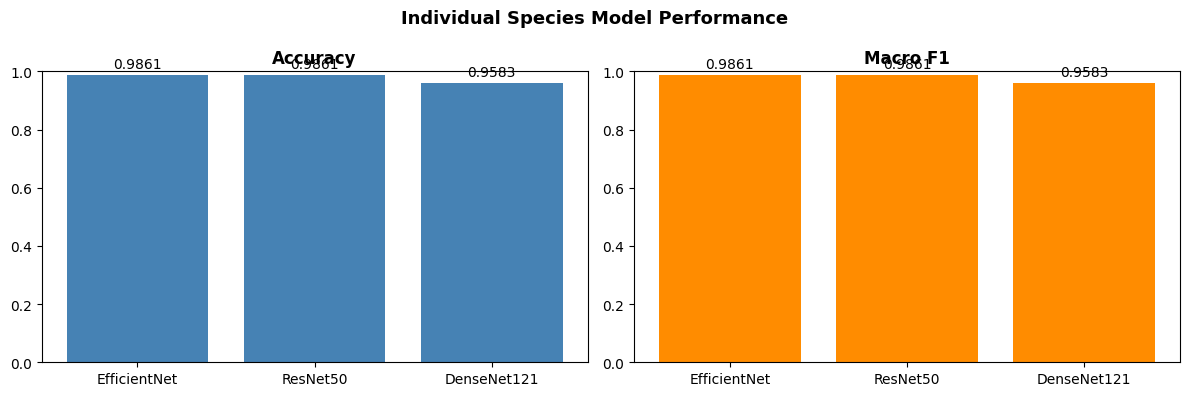

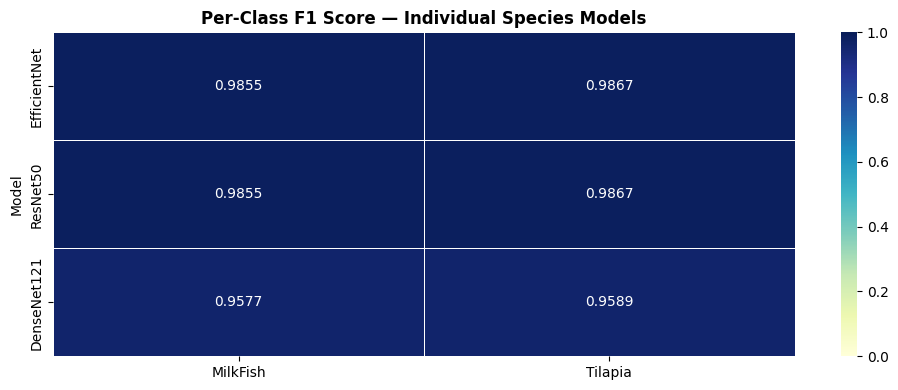

In [7]:
# ── Species: Classification Reports ─────────────────────────────────────────
for model_name, outputs in species_eval_outputs.items():
    print(f'\n--- {model_name} ---')
    print(classification_report(
        outputs['true'], outputs['preds'],
        target_names=species_class_names, zero_division=0, digits=4
    ))

# ── Species: Confusion Matrices ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (model_name, outputs) in zip(axes, species_eval_outputs.items()):
    sns.heatmap(
        outputs['cm'], annot=True, fmt='d', ax=ax,
        xticklabels=species_class_names, yticklabels=species_class_names,
        cmap='Blues', linewidths=0.5
    )
    acc = outputs['report']['accuracy']
    ax.set_title(f'{model_name}\nAccuracy: {acc:.4f}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
plt.suptitle('Confusion Matrices — Individual Species Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/SCHOOLFILES/CPE32/CPE313/final project/results_images/fish_class_conf_matrix.png',
                dpi=150, bbox_inches='tight')
plt.show()

# ── Species: Accuracy & Macro F1 Bar Chart ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, metric, color in zip(axes, ['Accuracy', 'Macro F1'], ['steelblue', 'darkorange']):
    sorted_df = species_eval_df.sort_values(metric, ascending=False)
    bars = ax.bar(sorted_df['Model'], sorted_df[metric], color=color)
    ax.set_ylim(0, 1)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.bar_label(bars, fmt='%.4f', padding=3)
plt.suptitle('Individual Species Model Performance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/SCHOOLFILES/CPE32/CPE313/final project/results_images/fish_class_accuracy.png',
                dpi=150, bbox_inches='tight')
plt.show()

# ── Species: Per-class F1 Heatmap ────────────────────────────────────────────
f1_rows = []
for model_name, outputs in species_eval_outputs.items():
    row = {'Model': model_name}
    for cls in species_class_names:
        row[cls] = round(outputs['report'][cls]['f1-score'], 4)
    f1_rows.append(row)

f1_df = pd.DataFrame(f1_rows).set_index('Model')
plt.figure(figsize=(10, 4))
sns.heatmap(f1_df, annot=True, fmt='.4f', cmap='YlGnBu', linewidths=0.5, vmin=0, vmax=1)
plt.title('Per-Class F1 Score — Individual Species Models', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/SCHOOLFILES/CPE32/CPE313/final project/results_images/fish_class_heatmap.png',
                dpi=150, bbox_inches='tight')
plt.show()

# ── Species: ROC-AUC Curves ───────────────────────────────────────────────────
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from itertools import cycle

n_classes = len(species_class_names)
colors = cycle(plt.cm.tab10.colors)

fig, axes = plt.subplots(1, len(species_eval_outputs), figsize=(7 * len(species_eval_outputs), 6))
if len(species_eval_outputs) == 1:
    axes = [axes]

for ax, (model_name, outputs) in zip(axes, species_eval_outputs.items()):
    # Binarize true labels
    y_true_bin = label_binarize(outputs['true'], classes=list(range(n_classes)))

    # outputs['probs'] must be an (N, n_classes) numpy array of softmax probabilities
    y_score = np.array(outputs['probs'])

    # Per-class ROC curves
    for i, (cls_name, color) in enumerate(zip(species_class_names, colors)):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=color, lw=1.8,
                label=f'{cls_name} (AUC = {roc_auc:.4f})')

    # Macro-average ROC
    all_fpr = np.unique(np.concatenate([
        roc_curve(y_true_bin[:, i], y_score[:, i])[0]
        for i in range(n_classes)
    ]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(n_classes):
        fpr_i, tpr_i, _ = roc_curve(y_true_bin[:, i], y_score[:, i])
        mean_tpr += np.interp(all_fpr, fpr_i, tpr_i)
    mean_tpr /= n_classes
    macro_auc = auc(all_fpr, mean_tpr)
    ax.plot(all_fpr, mean_tpr, color='black', lw=2.5, linestyle='--',
            label=f'Macro-avg (AUC = {macro_auc:.4f})')

    ax.plot([0, 1], [0, 1], 'k:', lw=1)          # chance line
    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(0.0, 1.05)
    ax.set_xlabel('False Positive Rate', fontsize=11)
    ax.set_ylabel('True Positive Rate', fontsize=11)
    ax.set_title(f'{model_name}\nROC-AUC Curves', fontsize=11, fontweight='bold')
    ax.legend(loc='lower right', fontsize=8)

plt.suptitle('ROC-AUC — Individual Species Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/SCHOOLFILES/CPE32/CPE313/final project/results_images/fish_class_roc_auc.png',
            dpi=150, bbox_inches='tight')

# ── Species: Overlapping ROC-AUC Curves (Model Comparison) ───────────────────
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

n_classes = len(species_class_names)
model_colors = ['steelblue', 'darkorange', 'seagreen', 'crimson', 'mediumpurple']

fig, ax = plt.subplots(figsize=(8, 7))

for (model_name, outputs), color in zip(species_eval_outputs.items(), model_colors):
    y_true_bin = label_binarize(outputs['true'], classes=list(range(n_classes)))
    y_score = np.array(outputs['probs'])

    # Macro-average ROC
    all_fpr = np.unique(np.concatenate([
        roc_curve(y_true_bin[:, i], y_score[:, i])[0]
        for i in range(n_classes)
    ]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(n_classes):
        fpr_i, tpr_i, _ = roc_curve(y_true_bin[:, i], y_score[:, i])
        mean_tpr += np.interp(all_fpr, fpr_i, tpr_i)
    mean_tpr /= n_classes
    macro_auc = auc(all_fpr, mean_tpr)

    ax.plot(all_fpr, mean_tpr, color=color, lw=2.2,
            label=f'{model_name} (AUC = {macro_auc:.4f})')

ax.plot([0, 1], [0, 1], 'k:', lw=1, label='Chance')
ax.set_xlim(0.0, 1.0)
ax.set_ylim(0.0, 1.05)
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC-AUC Comparison — All Species Models\n(Macro-Average per Model)',
             fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/SCHOOLFILES/CPE32/CPE313/final project/results_images/fish_class_roc_auc_overlap.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Individual Model Evaluation - Fish Disease Classification

In [8]:
# ── Individual Disease Model Evaluation ─────────────────────────────────────
# Loads the disease test set and evaluates each disease model independently.

disease_models = [
    ('EfficientNetB0', eff_disease,   'efficientnet'),
    ('ResNet50',       res_disease,   'resnet'),
    ('DenseNet121',    dense_disease, 'densenet'),
]

val_disease_data_eval = tf.keras.utils.image_dataset_from_directory(
    "/content/drive/MyDrive/SCHOOLFILES/CPE32/CPE313/final project/Freshwater Fish Disease Aquaculture in south asia/FreshWaterFishDiseases/Test",
    image_size=(224, 224),
    batch_size=32,
    label_mode='categorical',
    shuffle=False
)
disease_class_names = val_disease_data_eval.class_names
print('Disease classes:', disease_class_names)

disease_eval_results = []
disease_eval_outputs = {}

for model_name, model, backbone in disease_models:
    print(f'\nEvaluating {model_name} on disease classification...')
    all_preds = []
    all_true  = []
    all_confs = []
    all_probs = []   # ← full softmax vectors

    for images, labels in val_disease_data_eval:
        for i in range(len(images)):
            img = images[i].numpy()
            img = np.expand_dims(img, axis=0)
            img_p = preprocess_map[backbone](img.copy())
            pred  = model.predict(img_p, verbose=0)
            all_preds.append(int(np.argmax(pred)))
            all_confs.append(float(np.max(pred)))
            all_probs.append(pred[0].tolist())   # ← store full softmax vector
        all_true.extend(np.argmax(labels.numpy(), axis=1).tolist())

    all_preds = np.array(all_preds)
    all_true  = np.array(all_true)

    report = classification_report(
        all_true, all_preds,
        target_names=disease_class_names,
        output_dict=True,
        zero_division=0
    )
    cm = confusion_matrix(all_true, all_preds)

    disease_eval_outputs[model_name] = {
        'report':  report,
        'cm':      cm,
        'preds':   all_preds,
        'true':    all_true,
        'confs':   all_confs,
        'probs':   np.array(all_probs),   # ← shape (N, n_classes)
    }

    disease_eval_results.append({
        'Model':           model_name,
        'Accuracy':        round(report['accuracy'], 4),
        'Macro F1':        round(report['macro avg']['f1-score'], 4),
        'Macro Precision': round(report['macro avg']['precision'], 4),
        'Macro Recall':    round(report['macro avg']['recall'], 4),
        'Mean Confidence': round(float(np.mean(all_confs)), 4),
    })
    print(f'  Accuracy: {report["accuracy"]:.4f} | Macro F1: {report["macro avg"]["f1-score"]:.4f}')

disease_eval_df = pd.DataFrame(disease_eval_results).sort_values('Accuracy', ascending=False).reset_index(drop=True)
print('\n=== Individual Disease Model Comparison ===')
disease_eval_df


Found 72 files belonging to 4 classes.
Disease classes: ['Bacterial Red disease', 'Bacterial gill disease', 'Fungal diseases Saprolegniasis', 'Healthy']

Evaluating EfficientNetB0 on disease classification...
  Accuracy: 0.9583 | Macro F1: 0.9530

Evaluating ResNet50 on disease classification...
  Accuracy: 0.9583 | Macro F1: 0.9530

Evaluating DenseNet121 on disease classification...
  Accuracy: 0.9306 | Macro F1: 0.9282

=== Individual Disease Model Comparison ===


,Model,Accuracy,Macro F1,Macro Precision,Macro Recall,Mean Confidence
0,EfficientNetB0,0.9583,0.9530,0.9569,0.9507,0.9074
1,ResNet50,0.9583,0.9530,0.9569,0.9507,0.9152
2,DenseNet121,0.9306,0.9282,0.9679,0.9052,0.9018



--- EfficientNetB0 ---
                                precision    recall  f1-score   support

         Bacterial Red disease     0.8571    0.9231    0.8889        13
        Bacterial gill disease     1.0000    0.9091    0.9524        11
Fungal diseases Saprolegniasis     1.0000    1.0000    1.0000        14
                       Healthy     0.9706    0.9706    0.9706        34

                      accuracy                         0.9583        72
                     macro avg     0.9569    0.9507    0.9530        72
                  weighted avg     0.9603    0.9583    0.9588        72


--- ResNet50 ---
                                precision    recall  f1-score   support

         Bacterial Red disease     0.8571    0.9231    0.8889        13
        Bacterial gill disease     1.0000    0.9091    0.9524        11
Fungal diseases Saprolegniasis     1.0000    1.0000    1.0000        14
                       Healthy     0.9706    0.9706    0.9706        34

                 

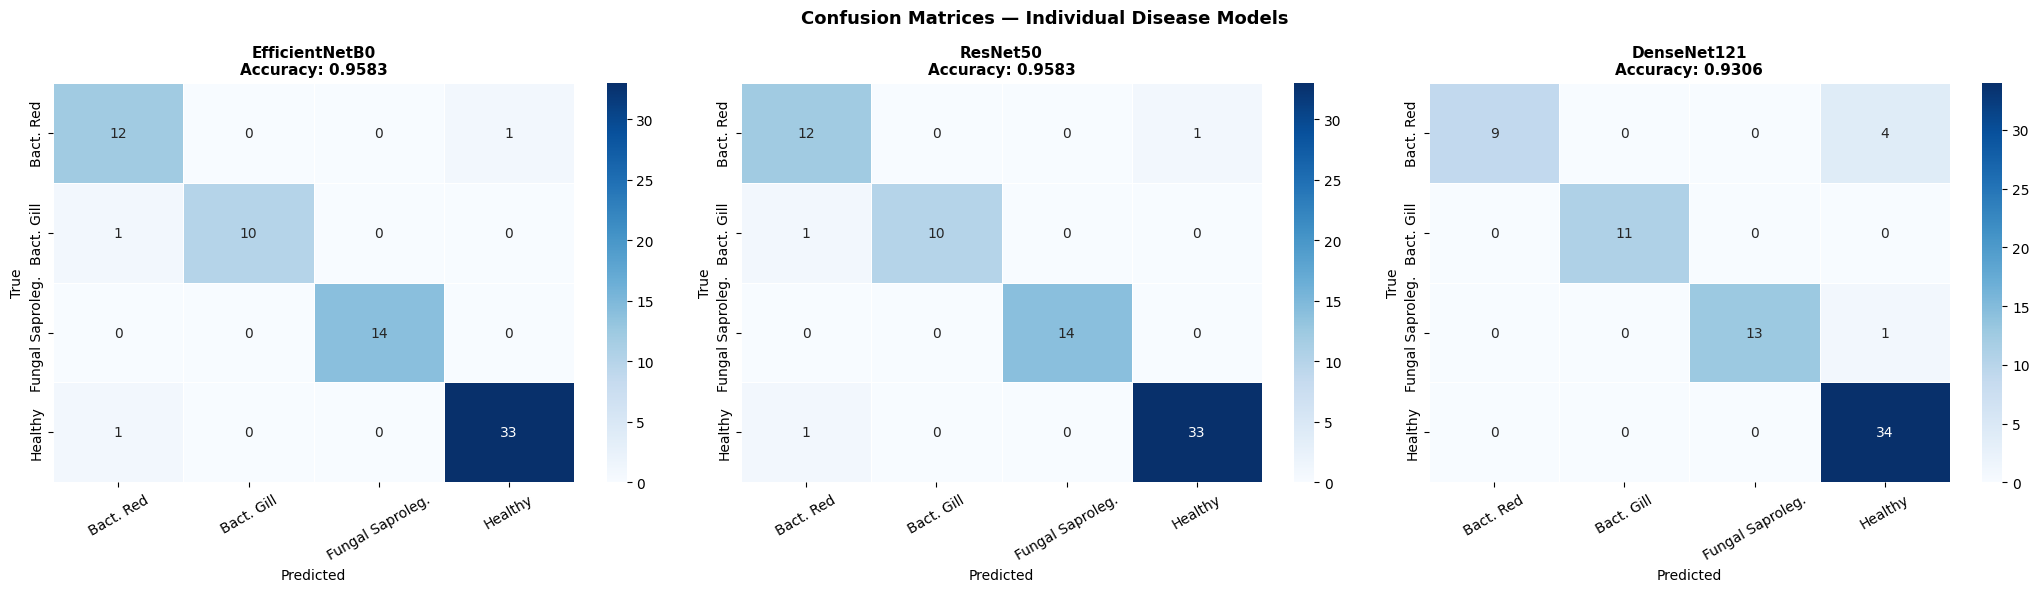

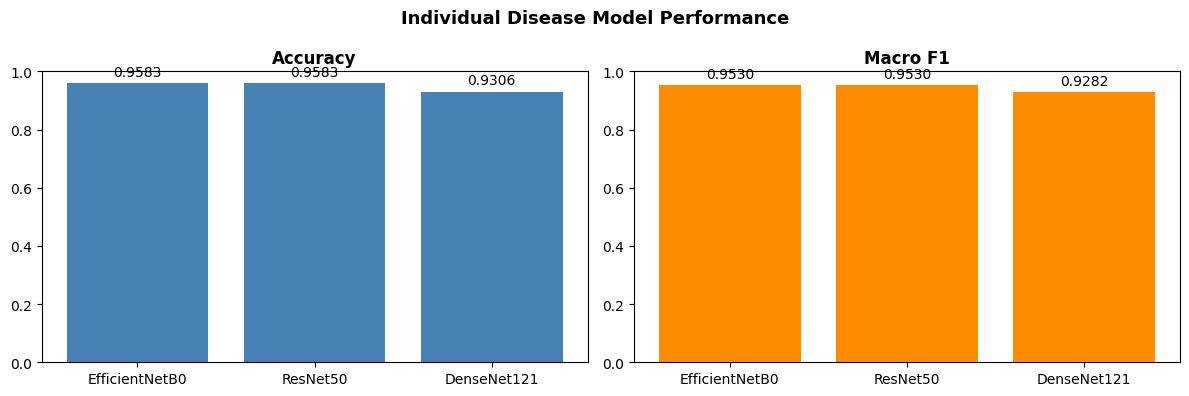

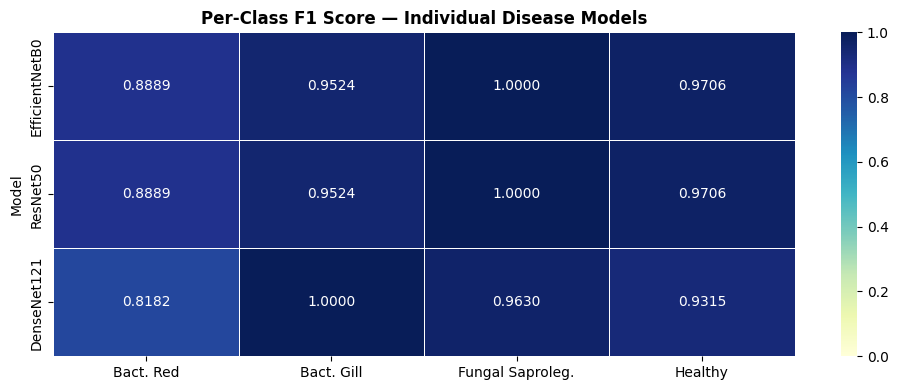

In [9]:
# ── Disease: Classification Reports ─────────────────────────────────────────
short_disease_labels = [
    'Bact. Red', 'Bact. Gill', 'Fungal Saproleg.', 'Healthy'
]
label_shortener = dict(zip(disease_class_names, short_disease_labels))

for model_name, outputs in disease_eval_outputs.items():
    print(f'\n--- {model_name} ---')
    print(classification_report(
        outputs['true'], outputs['preds'],
        target_names=disease_class_names, zero_division=0, digits=4
    ))

# ── Disease: Confusion Matrices ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(21, 6))
for ax, (model_name, outputs) in zip(axes, disease_eval_outputs.items()):
    sns.heatmap(
        outputs['cm'], annot=True, fmt='d', ax=ax,
        xticklabels=short_disease_labels, yticklabels=short_disease_labels,
        cmap='Blues', linewidths=0.5
    )
    acc = outputs['report']['accuracy']
    ax.set_title(f'{model_name}\nAccuracy: {acc:.4f}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.tick_params(axis='x', rotation=30)
plt.suptitle('Confusion Matrices — Individual Disease Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/SCHOOLFILES/CPE32/CPE313/final project/results_images/fish_dis_conf_mat.png',
                dpi=150, bbox_inches='tight')
plt.show()

# ── Disease: Accuracy & Macro F1 Bar Chart ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, metric, color in zip(axes, ['Accuracy', 'Macro F1'], ['steelblue', 'darkorange']):
    sorted_df = disease_eval_df.sort_values(metric, ascending=False)
    bars = ax.bar(sorted_df['Model'], sorted_df[metric], color=color)
    ax.set_ylim(0, 1)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.bar_label(bars, fmt='%.4f', padding=3)
plt.suptitle('Individual Disease Model Performance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/SCHOOLFILES/CPE32/CPE313/final project/results_images/fish_dis_accuracy.png',
                dpi=150, bbox_inches='tight')
plt.show()

# ── Disease: Per-class F1 Heatmap ────────────────────────────────────────────
f1_rows = []
for model_name, outputs in disease_eval_outputs.items():
    row = {'Model': model_name}
    for cls in disease_class_names:
        row[label_shortener[cls]] = round(outputs['report'][cls]['f1-score'], 4)
    f1_rows.append(row)

f1_df = pd.DataFrame(f1_rows).set_index('Model')
plt.figure(figsize=(10, 4))
sns.heatmap(f1_df, annot=True, fmt='.4f', cmap='YlGnBu', linewidths=0.5, vmin=0, vmax=1)
plt.title('Per-Class F1 Score — Individual Disease Models', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/SCHOOLFILES/CPE32/CPE313/final project/results_images/fish_dis_heatmap.png',
                dpi=150, bbox_inches='tight')
plt.show()


# ROC-AUC — Individual Disease Models

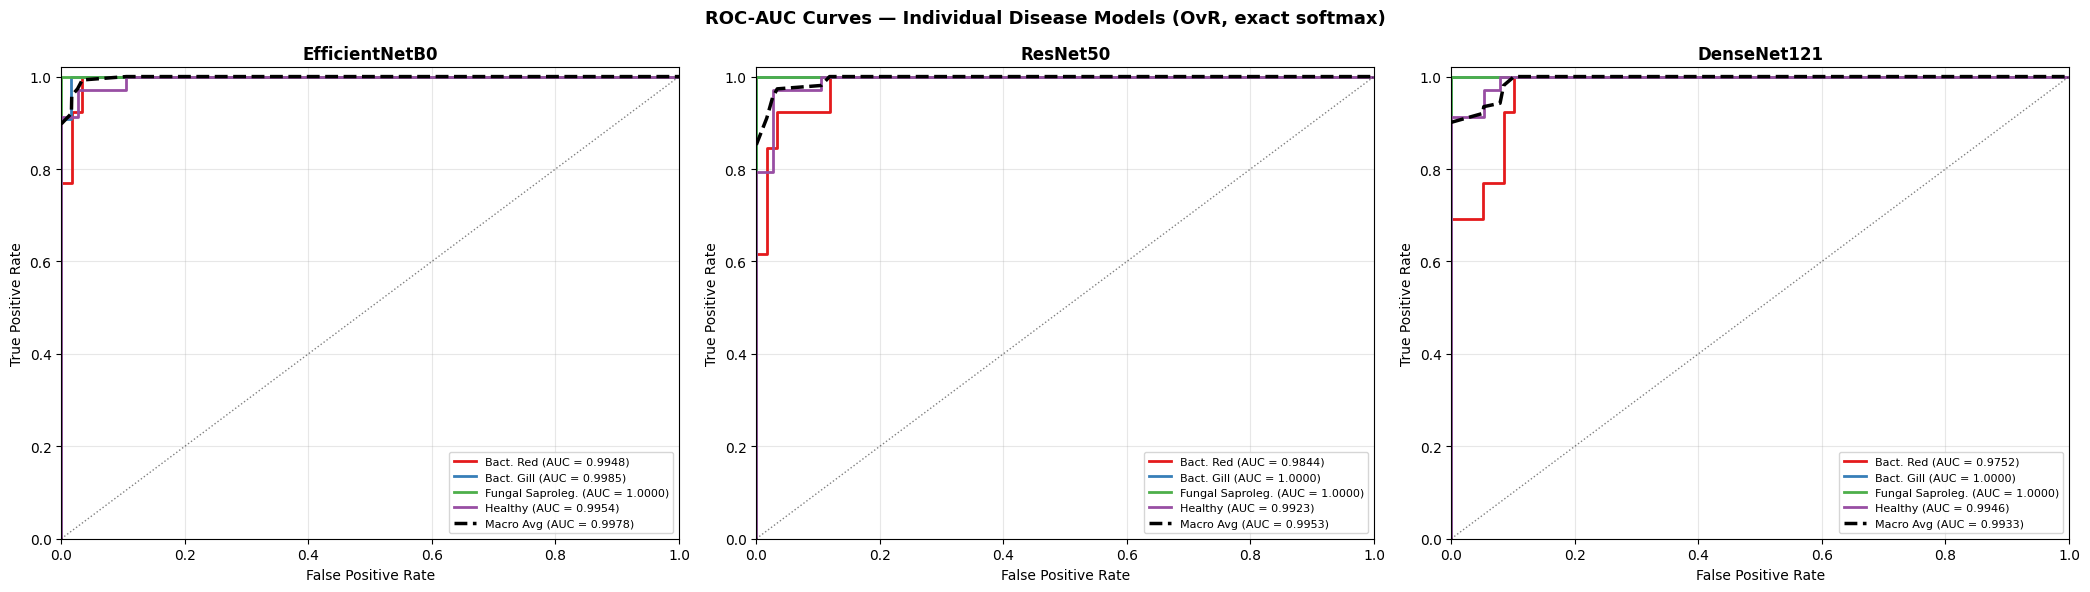

ROC-AUC (individual disease models) plotted.


In [10]:
# ── ROC-AUC: Individual Disease Models — Overlapping Curves ─────────────────
# Uses exact softmax probability vectors stored in disease_eval_outputs['probs'].

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

disease_models_list = list(disease_eval_outputs.keys())
n_classes = len(disease_class_names)
colors    = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']

fig, axes = plt.subplots(1, len(disease_models_list), figsize=(7 * len(disease_models_list), 6))
if len(disease_models_list) == 1:
    axes = [axes]

for ax, model_name in zip(axes, disease_models_list):
    outputs     = disease_eval_outputs[model_name]
    y_true      = label_binarize(outputs['true'], classes=list(range(n_classes)))
    prob_matrix = outputs['probs']   # exact softmax — shape (N, n_classes)

    fpr_list, tpr_list = [], []

    for i, cls_name in enumerate(disease_class_names):
        fpr, tpr, _ = roc_curve(y_true[:, i], prob_matrix[:, i])
        roc_auc     = auc(fpr, tpr)
        fpr_list.append(fpr)
        tpr_list.append(tpr)
        short = cls_name.replace('Fungal diseases Saprolegniasis', 'Fungal Saproleg.') \
                        .replace('Bacterial Red disease', 'Bact. Red') \
                        .replace('Bacterial gill disease', 'Bact. Gill')
        ax.plot(fpr, tpr, color=colors[i], lw=2,
                label=f'{short} (AUC = {roc_auc:.4f})')

    # Macro-average ROC
    all_fpr  = np.unique(np.concatenate(fpr_list))
    mean_tpr = np.zeros_like(all_fpr)
    for fpr_i, tpr_i in zip(fpr_list, tpr_list):
        mean_tpr += np.interp(all_fpr, fpr_i, tpr_i)
    mean_tpr /= n_classes
    macro_auc = auc(all_fpr, mean_tpr)
    ax.plot(all_fpr, mean_tpr, color='black', lw=2.5, linestyle='--',
            label=f'Macro Avg (AUC = {macro_auc:.4f})')

    ax.plot([0, 1], [0, 1], 'k:', lw=1, alpha=0.5)
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
    ax.set_xlabel('False Positive Rate', fontsize=10)
    ax.set_ylabel('True Positive Rate', fontsize=10)
    ax.set_title(f'{model_name}', fontsize=12, fontweight='bold')
    ax.legend(loc='lower right', fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('ROC-AUC Curves — Individual Disease Models (OvR, exact softmax)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/SCHOOLFILES/CPE32/CPE313/final project/results_images/roc_auc_individual_disease.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('ROC-AUC (individual disease models) plotted.')


# Run All Pipelines in Validation Set

In [11]:
val_disease_data = tf.keras.utils.image_dataset_from_directory(
    "/content/drive/MyDrive/SCHOOLFILES/CPE32/CPE313/final project/Freshwater Fish Disease Aquaculture in south asia/FreshWaterFishDiseases/Test",
    image_size=(224, 224),
    batch_size=32,
    label_mode='categorical',
    shuffle=False
)

val_species_data = tf.keras.utils.image_dataset_from_directory(
    "/content/drive/MyDrive/SCHOOLFILES/CPE32/CPE313/final project/Freshwater Fish Disease Aquaculture in south asia/FreshWaterFishClasses/Test",
    image_size=(224, 224),
    batch_size=32,
    label_mode='categorical',
    shuffle=False
)

results_summary  = []
pipeline_outputs = {}

for name, sm, dm, sb, db in pipelines:
    print(f'\nRunning pipeline: {name} ...')

    species_acc = get_species_accuracy(sm, sb, val_species_data)
    (report, cm,
     sp_preds, dp_preds, dp_true,
     sp_confs, dp_confs, jt_confs,
     dp_probs) = evaluate_pipeline_on_dataset(   # dp_probs: exact softmax (N, n_classes)
        sm, dm, sb, db, val_disease_data
    )

    # ── Option 1: Mean Joint Confidence ──────────────────────────────────────
    mean_joint_conf = float(np.mean(jt_confs))

    # ── Option 2: Confidence Correlation ─────────────────────────────────────
    conf_corr = float(np.corrcoef(sp_confs, dp_confs)[0, 1])

    # ── Option 3: Per-Species Disease Accuracy ────────────────────────────────
    per_species_acc = {}
    for sid, sname in enumerate(species_class_names):
        mask = [i for i, s in enumerate(sp_preds) if s == sid]
        if len(mask) == 0:
            per_species_acc[sname] = None
            continue
        correct = sum(dp_preds[i] == dp_true[i] for i in mask)
        per_species_acc[sname] = round(correct / len(mask), 4)

    # ── Option 4: Cascade Confidence Drop ────────────────────────────────────
    conf_drop = float(np.mean(sp_confs) - np.mean(dp_confs))

    pipeline_outputs[name] = {
        'report':           report,
        'cm':               cm,
        'species_preds':    sp_preds,
        'disease_preds':    dp_preds,
        'disease_true':     dp_true,
        'species_confs':    sp_confs,
        'disease_confs':    dp_confs,
        'joint_confs':      jt_confs,
        'disease_probs':    dp_probs,           # ← exact softmax vectors
        'mean_joint_conf':  mean_joint_conf,
        'conf_corr':        conf_corr,
        'per_species_acc':  per_species_acc,
        'conf_drop':        conf_drop,
    }

    row = {
        'Pipeline':         name,
        'Species Accuracy': round(species_acc, 4),
        'Disease Accuracy': round(report['accuracy'], 4),
        'Macro F1':         round(report['macro avg']['f1-score'], 4),
        'Macro Precision':  round(report['macro avg']['precision'], 4),
        'Macro Recall':     round(report['macro avg']['recall'], 4),
        'Mean Joint Conf':  round(mean_joint_conf, 4),   # Option 1
        'Conf Correlation': round(conf_corr, 4),          # Option 2
        'Conf Drop':        round(conf_drop, 4),          # Option 4
    }
    # Option 3 — one column per species
    for sname, acc in per_species_acc.items():
        row[f'DiseaseAcc ({sname})'] = acc if acc is not None else 'N/A'

    results_summary.append(row)

    print(f'  Species Acc:   {species_acc:.4f} | Disease Acc: {report["accuracy"]:.4f} | Macro F1: {report["macro avg"]["f1-score"]:.4f}')
    print(f'  Joint Conf:    {mean_joint_conf:.4f} | Conf Corr:   {conf_corr:.4f} | Conf Drop: {conf_drop:.4f}')
    for sname, acc in per_species_acc.items():
        print(f'  DiseaseAcc ({sname}): {acc}')

    tf.keras.backend.clear_session()

results_df = pd.DataFrame(results_summary).sort_values('Disease Accuracy', ascending=False)
print('\n=== Pipeline Comparison Summary ===')
results_df

Found 72 files belonging to 4 classes.
Found 72 files belonging to 2 classes.

Running pipeline: EfficientNet → ResNet ...
  Species Acc:   0.9861 | Disease Acc: 0.9583 | Macro F1: 0.9530
  Joint Conf:    0.8751 | Conf Corr:   -0.1432 | Conf Drop: 0.0422
  DiseaseAcc (MilkFish): 0.9706
  DiseaseAcc (Tilapia): 0.9474

Running pipeline: EfficientNet → DenseNet ...
  Species Acc:   0.9861 | Disease Acc: 0.9306 | Macro F1: 0.9282
  Joint Conf:    0.8633 | Conf Corr:   -0.0147 | Conf Drop: 0.0556
  DiseaseAcc (MilkFish): 0.9706
  DiseaseAcc (Tilapia): 0.8947

Running pipeline: ResNet → EfficientNet ...
  Species Acc:   0.9861 | Disease Acc: 0.9583 | Macro F1: 0.9530
  Joint Conf:    0.8717 | Conf Corr:   0.2712 | Conf Drop: 0.0496
  DiseaseAcc (MilkFish): 0.9706
  DiseaseAcc (Tilapia): 0.9474

Running pipeline: ResNet → DenseNet ...
  Species Acc:   0.9861 | Disease Acc: 0.9306 | Macro F1: 0.9282
  Joint Conf:    0.8653 | Conf Corr:   0.1913 | Conf Drop: 0.0552
  DiseaseAcc (MilkFish): 0.97

,Pipeline,Species Accuracy,Disease Accuracy,Macro F1,Macro Precision,Macro Recall,Mean Joint Conf,Conf Correlation,Conf Drop,DiseaseAcc (MilkFish),DiseaseAcc (Tilapia)
0,EfficientNet → ResNet,0.9861,0.9583,0.9530,0.9569,0.9507,0.8751,-0.1432,0.0422,0.9706,0.9474
2,ResNet → EfficientNet,0.9861,0.9583,0.9530,0.9569,0.9507,0.8717,0.2712,0.0496,0.9706,0.9474
5,DenseNet → ResNet,0.9583,0.9583,0.9530,0.9569,0.9507,0.8432,0.0238,0.0058,0.9722,0.9444
4,DenseNet → EfficientNet,0.9583,0.9583,0.9530,0.9569,0.9507,0.8350,-0.0556,0.0136,0.9722,0.9444
1,EfficientNet → DenseNet,0.9861,0.9306,0.9282,0.9679,0.9052,0.8633,-0.0147,0.0556,0.9706,0.8947
3,ResNet → DenseNet,0.9861,0.9306,0.9282,0.9679,0.9052,0.8653,0.1913,0.0552,0.9706,0.8947


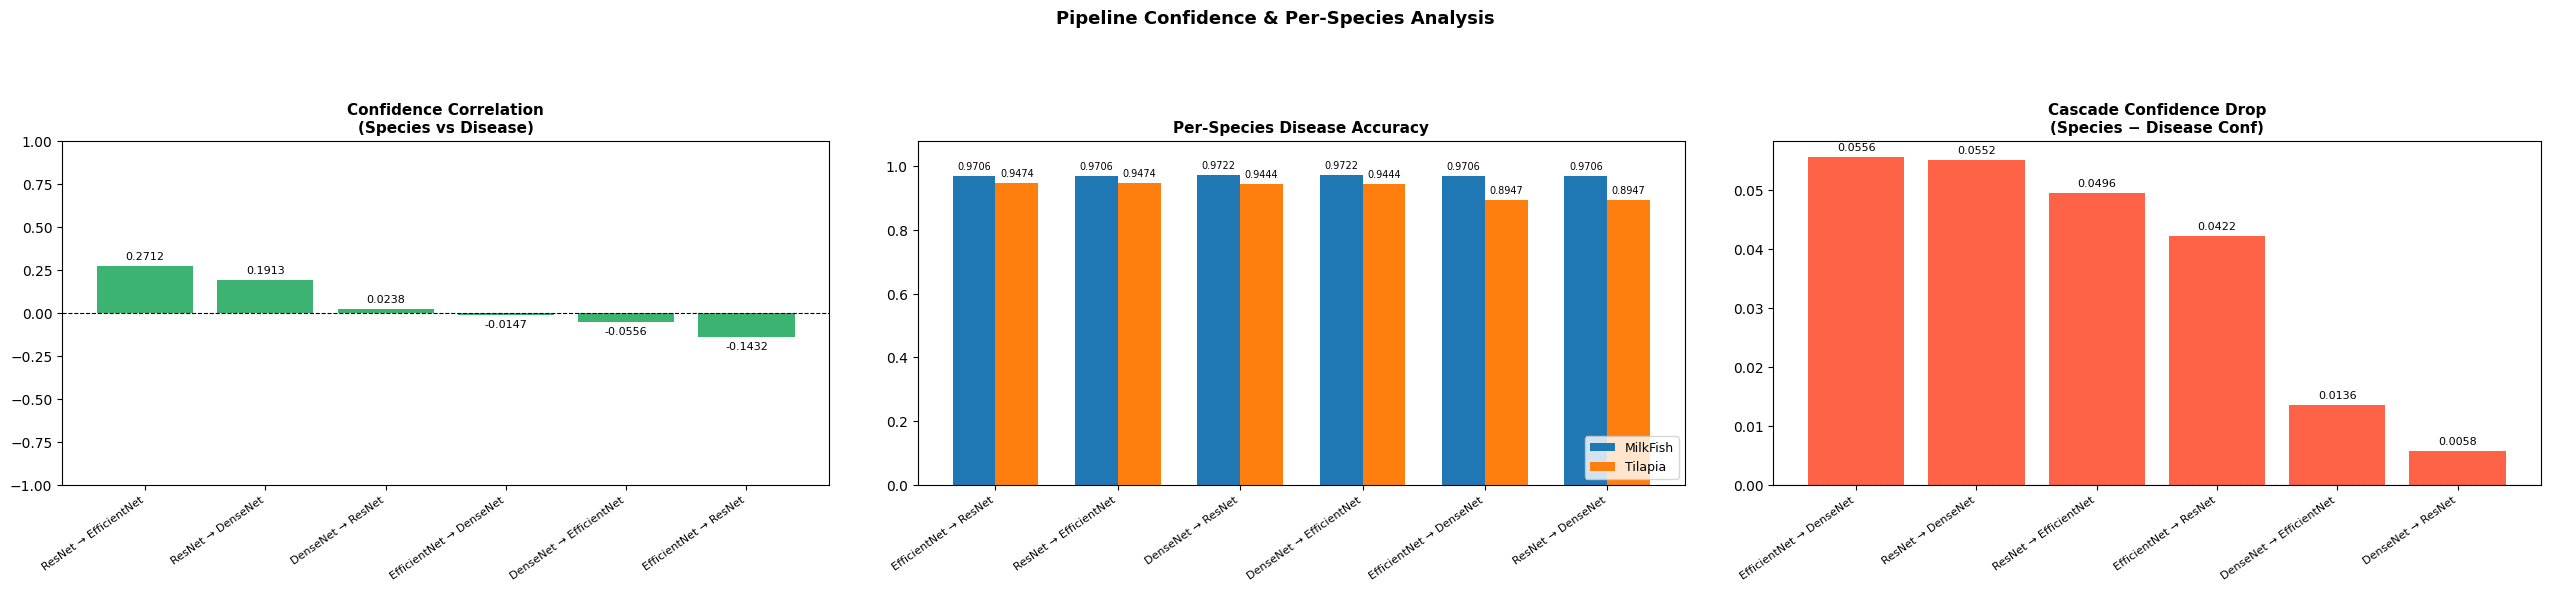

In [12]:
# ── Option 2: Confidence Correlation Bar Chart ────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(26, 6))  # wider + taller

ax = axes[0]
sorted_df = results_df.sort_values('Conf Correlation', ascending=False)
bars = ax.bar(sorted_df['Pipeline'], sorted_df['Conf Correlation'], color='mediumseagreen')
ax.set_ylim(-1, 1)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Confidence Correlation\n(Species vs Disease)', fontsize=11, fontweight='bold')
ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=8)
ax.tick_params(axis='x', labelsize=8)
plt.setp(ax.get_xticklabels(), rotation=35, ha='right')  # rotate labels

# ── Option 3: Per-Species Disease Accuracy Grouped Bar Chart ─────────────────
ax = axes[1]
species_cols = [c for c in results_df.columns if c.startswith('DiseaseAcc (')]
x = np.arange(len(results_df))
width = 0.35
for i, col in enumerate(species_cols):
    vals = pd.to_numeric(results_df[col], errors='coerce')
    bars = ax.bar(x + i * width, vals, width, label=col.replace('DiseaseAcc (', '').replace(')', ''))
    ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=7)  # smaller label font
ax.set_xticks(x + width / 2)
ax.set_xticklabels(results_df['Pipeline'], fontsize=8)
ax.set_ylim(0, 1.08)  # extra headroom for bar labels
ax.set_title('Per-Species Disease Accuracy', fontsize=11, fontweight='bold')
ax.legend(fontsize=9, loc='lower right')
plt.setp(ax.get_xticklabels(), rotation=35, ha='right')  # rotate labels

# ── Option 4: Cascade Confidence Drop Bar Chart ───────────────────────────────
ax = axes[2]
sorted_df = results_df.sort_values('Conf Drop', ascending=False)
colors = ['tomato' if v >= 0 else 'steelblue' for v in sorted_df['Conf Drop']]
bars = ax.bar(sorted_df['Pipeline'], sorted_df['Conf Drop'], color=colors)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Cascade Confidence Drop\n(Species − Disease Conf)', fontsize=11, fontweight='bold')
ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=8)
ax.tick_params(axis='x', labelsize=8)
plt.setp(ax.get_xticklabels(), rotation=35, ha='right')  # rotate labels

plt.suptitle('Pipeline Confidence & Per-Species Analysis', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout(pad=2.5)  # more padding between subplots
plt.savefig('/content/drive/MyDrive/SCHOOLFILES/CPE32/CPE313/final project/results_images/pipeline_confidence_analysis.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Confidence Test

In [13]:
import os, random

# ── Paths ──────────────────────────────────────────────────────────────────────
DISEASE_ROOT      = '/content/drive/MyDrive/SCHOOLFILES/CPE32/CPE313/final project/Freshwater Fish Disease Aquaculture in south asia/FreshWaterFishDiseases/Test'
SPECIES_ROOT      = '/content/drive/MyDrive/SCHOOLFILES/CPE32/CPE313/final project/Freshwater Fish Disease Aquaculture in south asia/FreshWaterFishClasses/Test'

SAMPLES_PER_CLASS = 5
VALID_EXTS        = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
BEST_SEED         = 3

def sample_class_dir(root, n=SAMPLES_PER_CLASS, seed=None):
    rng = random.Random(seed)
    class_samples = {}
    if not os.path.isdir(root):
        print(f'[WARN] Directory not found: {root}')
        return class_samples
    for cls in sorted(os.listdir(root)):
        cls_dir = os.path.join(root, cls)
        if not os.path.isdir(cls_dir):
            continue
        imgs = [
            os.path.join(cls_dir, f)
            for f in os.listdir(cls_dir)
            if os.path.splitext(f)[1].lower() in VALID_EXTS
        ]
        if not imgs:
            continue
        class_samples[cls] = rng.sample(imgs, min(n, len(imgs)))
    return class_samples

def run_confidence_test(seed):
    disease_samples = sample_class_dir(DISEASE_ROOT, seed=seed)
    species_samples = sample_class_dir(SPECIES_ROOT, seed=seed)
    rows = []
    for domain, class_samples in [('Disease', disease_samples), ('Species', species_samples)]:
        for true_label, img_paths in class_samples.items():
            for img_path in img_paths:
                img     = keras_image.load_img(img_path, target_size=(224, 224))
                img_arr = keras_image.img_to_array(img)
                img_arr = np.expand_dims(img_arr, axis=0)
                for name, sm, dm, sb, db in pipelines:
                    result = run_pipeline(img_arr, sm, dm, sb, db)
                    rows.append({
                        'Pipeline':          name,
                        'Domain':            domain,
                        'True Label':        true_label,
                        'Predicted Species': result['species'],
                        'Species Conf':      round(result['species_conf'], 4),
                        'Predicted Disease': result['disease'],
                        'Disease Conf':      round(result['disease_conf'], 4),
                        'Joint Conf':        round(result['joint_conf'], 4),
                        'Correct':           (
                            result['disease'] == true_label if domain == 'Disease'
                            else result['species'] == true_label
                        ),
                    })
    return pd.DataFrame(rows), disease_samples, species_samples

# ── Run with best seed ─────────────────────────────────────────────────────────
print(f'Running confidence test with seed {BEST_SEED} ...')
conf_df, disease_samples, species_samples = run_confidence_test(BEST_SEED)

conf_df = (
    conf_df
    .sort_values(['Pipeline', 'Domain', 'True Label'])
    .reset_index(drop=True)
)

print('=== Confidence Test — Disease & Species Classes ===')
print(f'Disease classes : {sorted(disease_samples.keys())}')
print(f'Species classes : {sorted(species_samples.keys())}')
print(f'Samples/class   : {SAMPLES_PER_CLASS}')
print(f'Total rows      : {len(conf_df)}')
conf_df

OUTPUT_PATH = '/content/drive/MyDrive/SCHOOLFILES/CPE32/CPE313/final project/confidence_test_results.xlsx'
conf_df.to_excel(OUTPUT_PATH, index=False)
print(f'Saved to {OUTPUT_PATH}')

Running confidence test with seed 3 ...
=== Confidence Test — Disease & Species Classes ===
Disease classes : ['Bacterial Red disease', 'Bacterial gill disease', 'Fungal diseases Saprolegniasis', 'Healthy']
Species classes : ['MilkFish', 'Tilapia']
Samples/class   : 5
Total rows      : 180
Saved to /content/drive/MyDrive/SCHOOLFILES/CPE32/CPE313/final project/confidence_test_results.xlsx


# Error Propagation Analysis

In [14]:
propagation_rows = []

for name, outputs in pipeline_outputs.items():
    dp      = np.array(outputs['disease_preds'])
    dt      = np.array(outputs['disease_true'])
    sp_conf = np.array(outputs['species_confs'])
    jt_conf = np.array(outputs['joint_confs'])

    disease_wrong = (dp != dt)

    # Mean species confidence on wrong disease predictions
    # Low species confidence on errors suggests Stage 1 uncertainty propagated
    mean_sp_conf_on_errors = (
        float(np.mean(sp_conf[disease_wrong])) if disease_wrong.sum() > 0 else None
    )

    propagation_rows.append({
        'Pipeline':                      name,
        'Total Samples':                 len(dt),
        'Total Errors':                  int(disease_wrong.sum()),
        'Error Rate':                    round(float(disease_wrong.mean()), 4),
        'Mean Species Conf (Overall)':   round(float(np.mean(sp_conf)), 4),
        'Mean Species Conf (On Errors)': (
            round(mean_sp_conf_on_errors, 4) if mean_sp_conf_on_errors is not None else 'N/A'
        ),
        'Mean Joint Conf':               round(float(np.mean(jt_conf)), 4),
    })

prop_df = pd.DataFrame(propagation_rows).sort_values('Error Rate')
print('=== Error Propagation Analysis ===')
prop_df

=== Error Propagation Analysis ===


,Pipeline,Total Samples,Total Errors,Error Rate,Mean Species Conf (Overall),Mean Species Conf (On Errors),Mean Joint Conf
0,EfficientNet → ResNet,72,3,0.0417,0.9574,0.9942,0.8751
2,ResNet → EfficientNet,72,3,0.0417,0.9570,0.8943,0.8717
5,DenseNet → ResNet,72,3,0.0417,0.9210,0.9626,0.8432
4,DenseNet → EfficientNet,72,3,0.0417,0.9210,0.9626,0.8350
3,ResNet → DenseNet,72,5,0.0694,0.9570,0.8933,0.8653
1,EfficientNet → DenseNet,72,5,0.0694,0.9574,0.9668,0.8633


# Visualizations

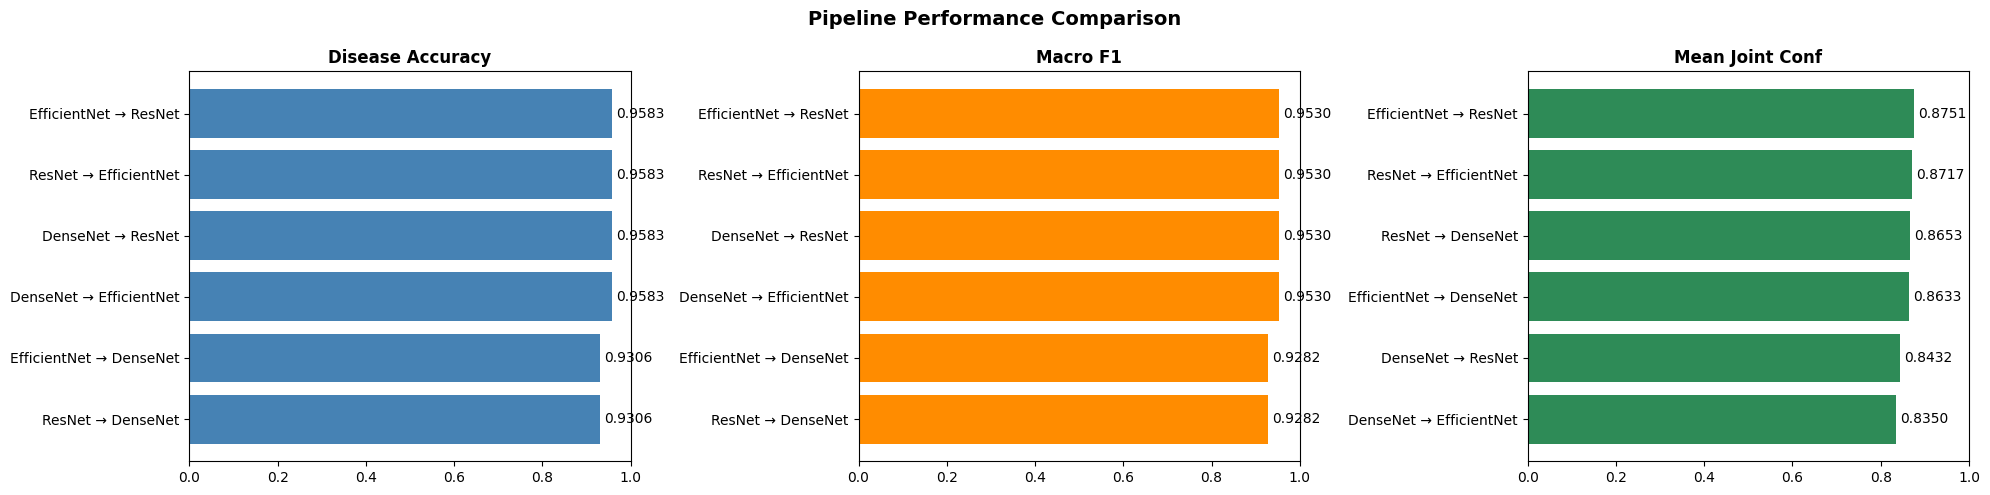

In [15]:
# ── Chart 1: Accuracy, Macro F1, Mean Joint Confidence ──────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

metrics = [
    ('Disease Accuracy', 'steelblue'),
    ('Macro F1',         'darkorange'),
    ('Mean Joint Conf',  'seagreen'),
]

for ax, (metric, color) in zip(axes, metrics):
    sorted_df = results_df.sort_values(metric, ascending=False)
    bars = ax.barh(sorted_df['Pipeline'], sorted_df[metric], color=color)
    ax.set_xlim(0, 1)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.bar_label(bars, fmt='%.4f', padding=3)
    ax.invert_yaxis()

plt.suptitle('Pipeline Performance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/SCHOOLFILES/CPE32/CPE313/final project/results_images/pipeline_eval.png',
                dpi=150, bbox_inches='tight')
plt.show()

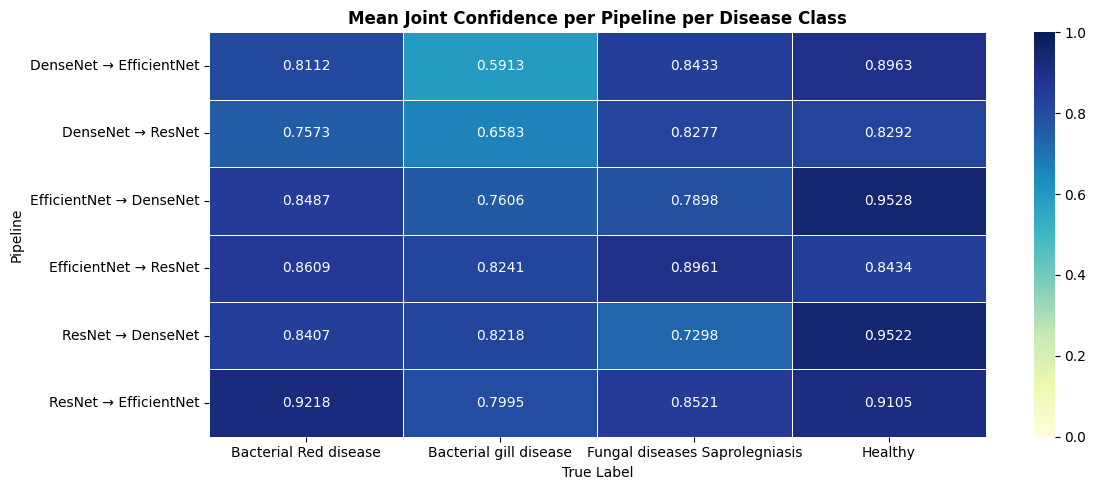

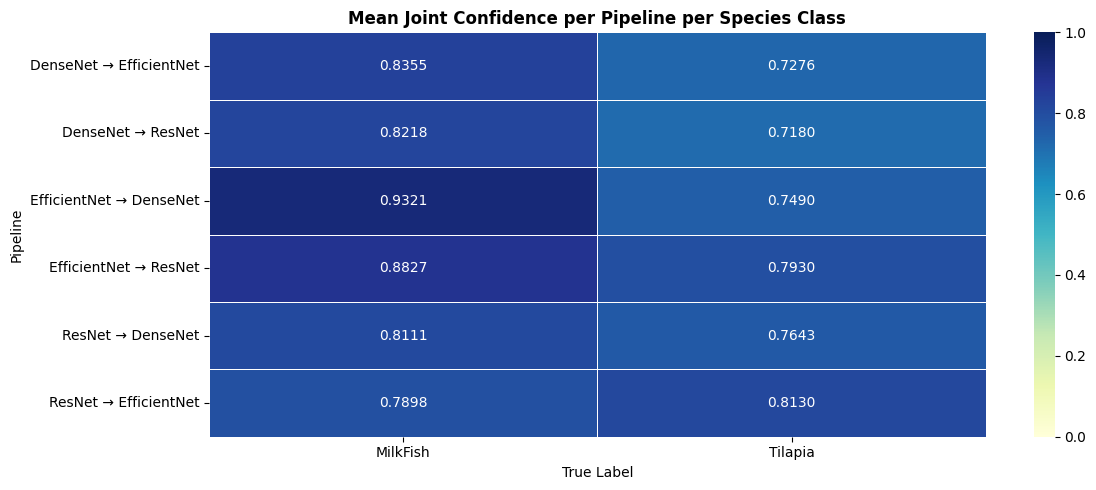

In [16]:
# ── Chart 2: Joint Confidence Heatmap ───────────────────────────────────────
for domain in ['Disease', 'Species']:
    subset = conf_df[conf_df['Domain'] == domain]

    pivot = subset.pivot_table(
        index='Pipeline', columns='True Label',
        values='Joint Conf', aggfunc='mean'
    )

    plt.figure(figsize=(12, 5))
    sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlGnBu',
                linewidths=0.5, vmin=0, vmax=1)
    plt.title(f'Mean Joint Confidence per Pipeline per {domain} Class',
              fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/SCHOOLFILES/CPE32/CPE313/final project/results_images/pipeline_joint_confidence_heatmap.png',
                dpi=150, bbox_inches='tight')
    plt.show()

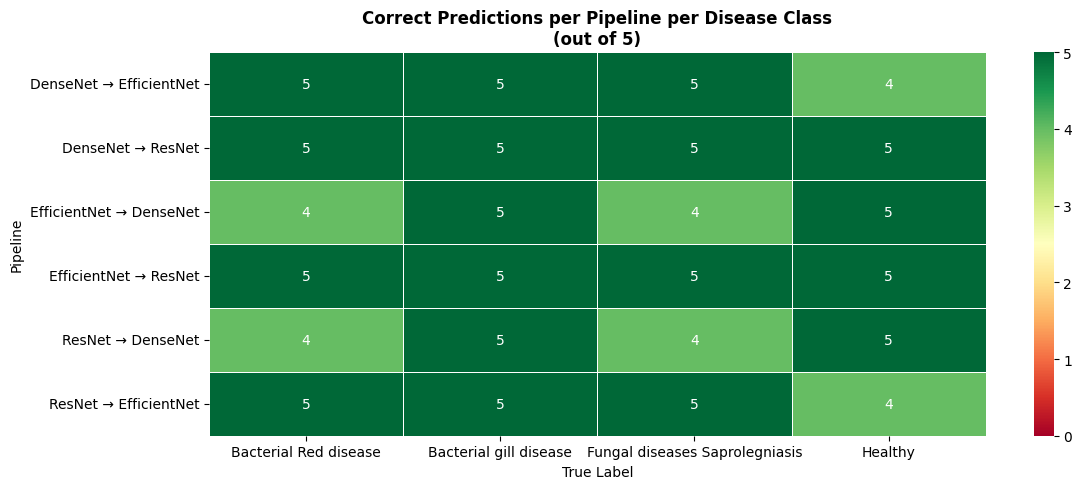

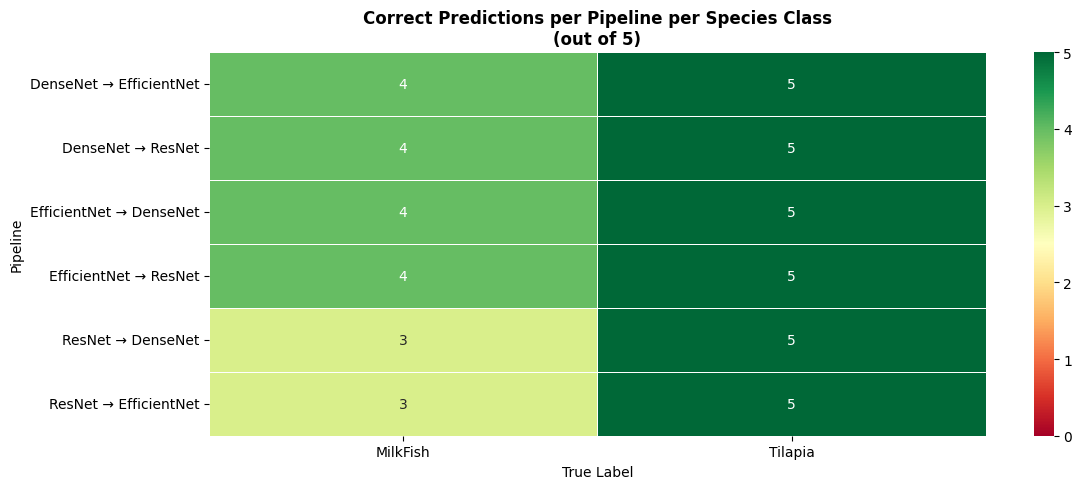

In [17]:
# ── Chart 3: Correctness per Pipeline ───────────────────────────────────────
for domain in ['Disease', 'Species']:
    subset = conf_df[conf_df['Domain'] == domain]

    correct_pivot = subset.pivot_table(
        index='Pipeline', columns='True Label',
        values='Correct', aggfunc='sum'
    )

    plt.figure(figsize=(12, 5))
    sns.heatmap(correct_pivot, annot=True, fmt='.0f', cmap='RdYlGn',
                linewidths=0.5, vmin=0, vmax=SAMPLES_PER_CLASS)
    plt.title(f'Correct Predictions per Pipeline per {domain} Class\n(out of {SAMPLES_PER_CLASS})',
              fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/SCHOOLFILES/CPE32/CPE313/final project/results_images/pipeline_correctness.png',
                dpi=150, bbox_inches='tight')
    plt.show()

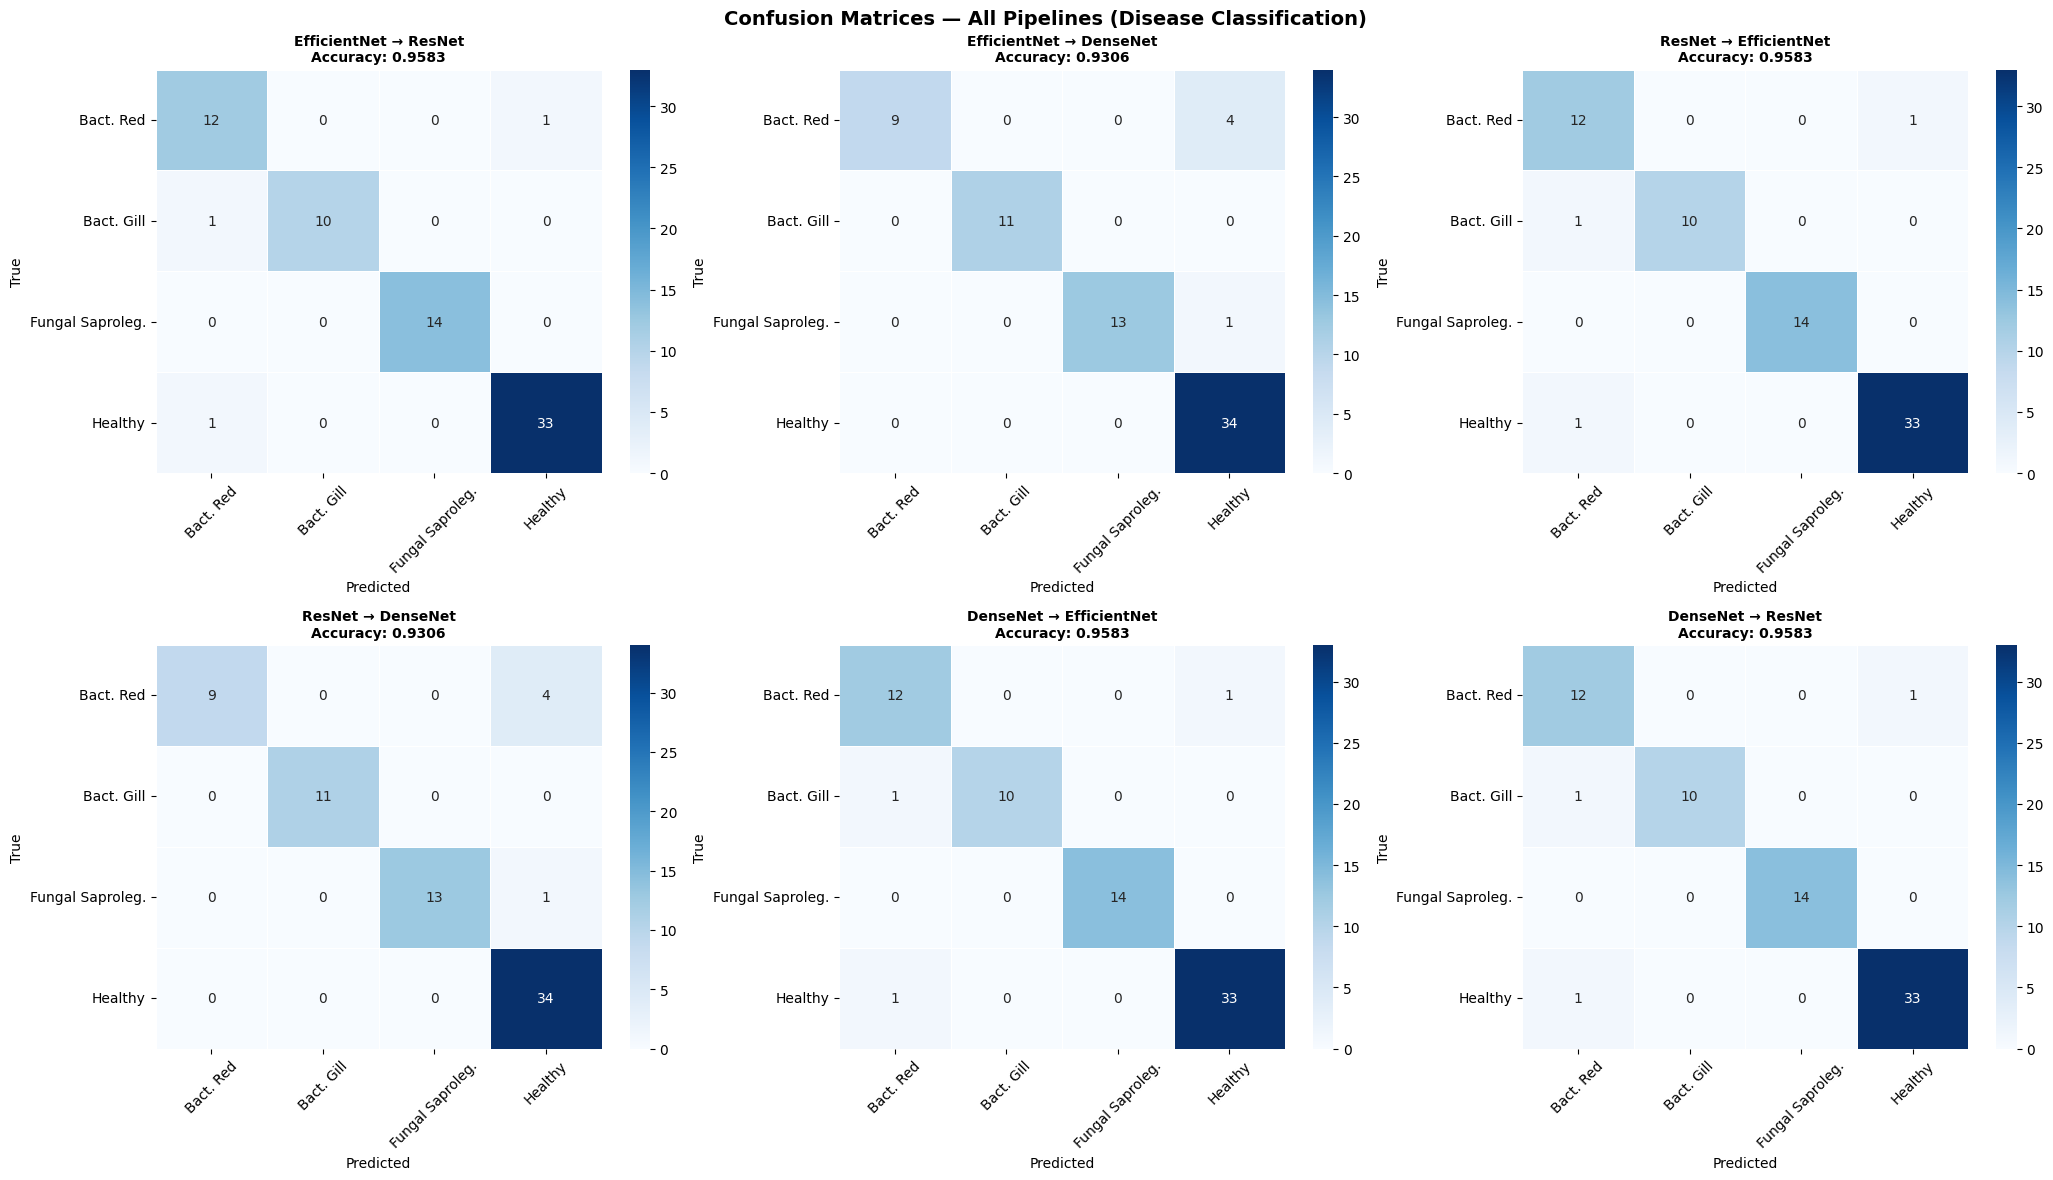

In [18]:
import math
# ── Chart 4: Confusion Matrices for all pipelines ───────────────────────────
disease_classes = val_disease_data.class_names

# Shorten long class names for display
label_map = {c: c for c in disease_classes}  # identity by default
label_map.update({
    'Bacterial Red disease':          'Bact. Red',
    'Bacterial gill disease':         'Bact. Gill',
    'Fungal diseases Saprolegniasis': 'Fungal Saproleg.',
    'Healthy':                        'Healthy',
})
short_labels = [label_map.get(c, c) for c in disease_classes]

n_pipelines = len(pipeline_outputs)
n_cols      = 3
n_rows      = math.ceil(n_pipelines / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(7 * n_cols, 6 * n_rows))
axes = axes.flatten()

for idx, (name, outputs) in enumerate(pipeline_outputs.items()):
    sns.heatmap(
        outputs['cm'], annot=True, fmt='d', ax=axes[idx],
        xticklabels=short_labels, yticklabels=short_labels,
        cmap='Blues', linewidths=0.5
    )
    acc = outputs['report']['accuracy']
    axes[idx].set_title(f'{name}\nAccuracy: {acc:.4f}', fontsize=10, fontweight='bold')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('True')
    axes[idx].tick_params(axis='x', rotation=45)
    axes[idx].tick_params(axis='y', rotation=0)

for idx in range(n_pipelines, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Confusion Matrices — All Pipelines (Disease Classification)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.suptitle('Confusion Matrices — All Pipelines (Disease Classification)',
                 fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/SCHOOLFILES/CPE32/CPE313/final project/results_images/pipeline_confusion_matrices.png',
                dpi=150, bbox_inches='tight')
plt.show()

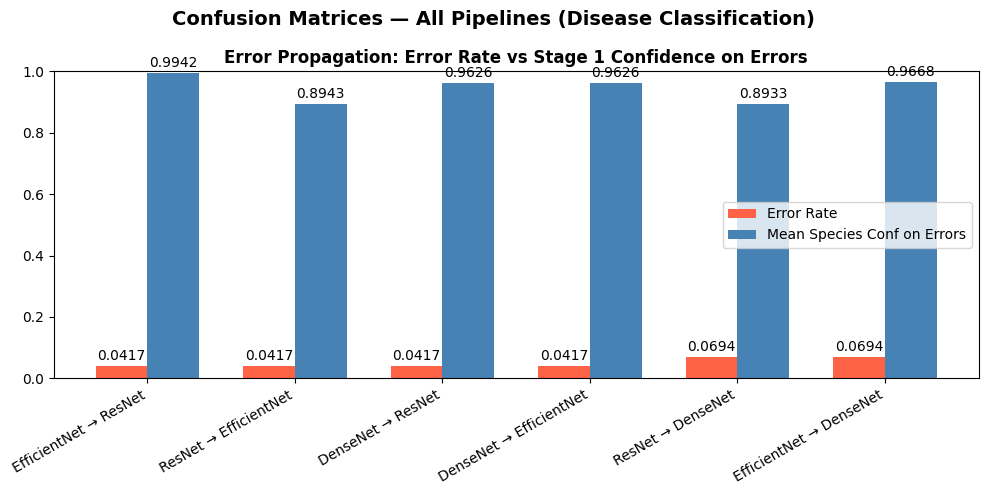

In [19]:
# ── Chart 5: Error Propagation — Error Rate vs Mean Species Confidence ───────
fig, ax = plt.subplots(figsize=(10, 5))

prop_plot = prop_df[prop_df['Mean Species Conf (On Errors)'] != 'N/A'].copy()
prop_plot['Mean Species Conf (On Errors)'] = prop_plot['Mean Species Conf (On Errors)'].astype(float)

x     = np.arange(len(prop_plot))
width = 0.35

bars1 = ax.bar(x - width/2, prop_plot['Error Rate'],
               width, label='Error Rate', color='tomato')
bars2 = ax.bar(x + width/2, prop_plot['Mean Species Conf (On Errors)'],
               width, label='Mean Species Conf on Errors', color='steelblue')

ax.set_xticks(x)
ax.set_xticklabels(prop_plot['Pipeline'], rotation=30, ha='right')
ax.set_ylim(0, 1)
ax.set_title('Error Propagation: Error Rate vs Stage 1 Confidence on Errors',
             fontsize=12, fontweight='bold')
ax.legend()
ax.bar_label(bars1, fmt='%.4f', padding=2)
ax.bar_label(bars2, fmt='%.4f', padding=2)

plt.tight_layout()
plt.suptitle('Confusion Matrices — All Pipelines (Disease Classification)',
                 fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/SCHOOLFILES/CPE32/CPE313/final project/results_images/pipeline_error_propagation.png',
                dpi=150, bbox_inches='tight')
plt.show()

# ROC-AUC — All Pipelines (Disease Stage)

/tmp/ipykernel_1987/1824247373.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap           = cm.get_cmap('tab10', n_pipelines)


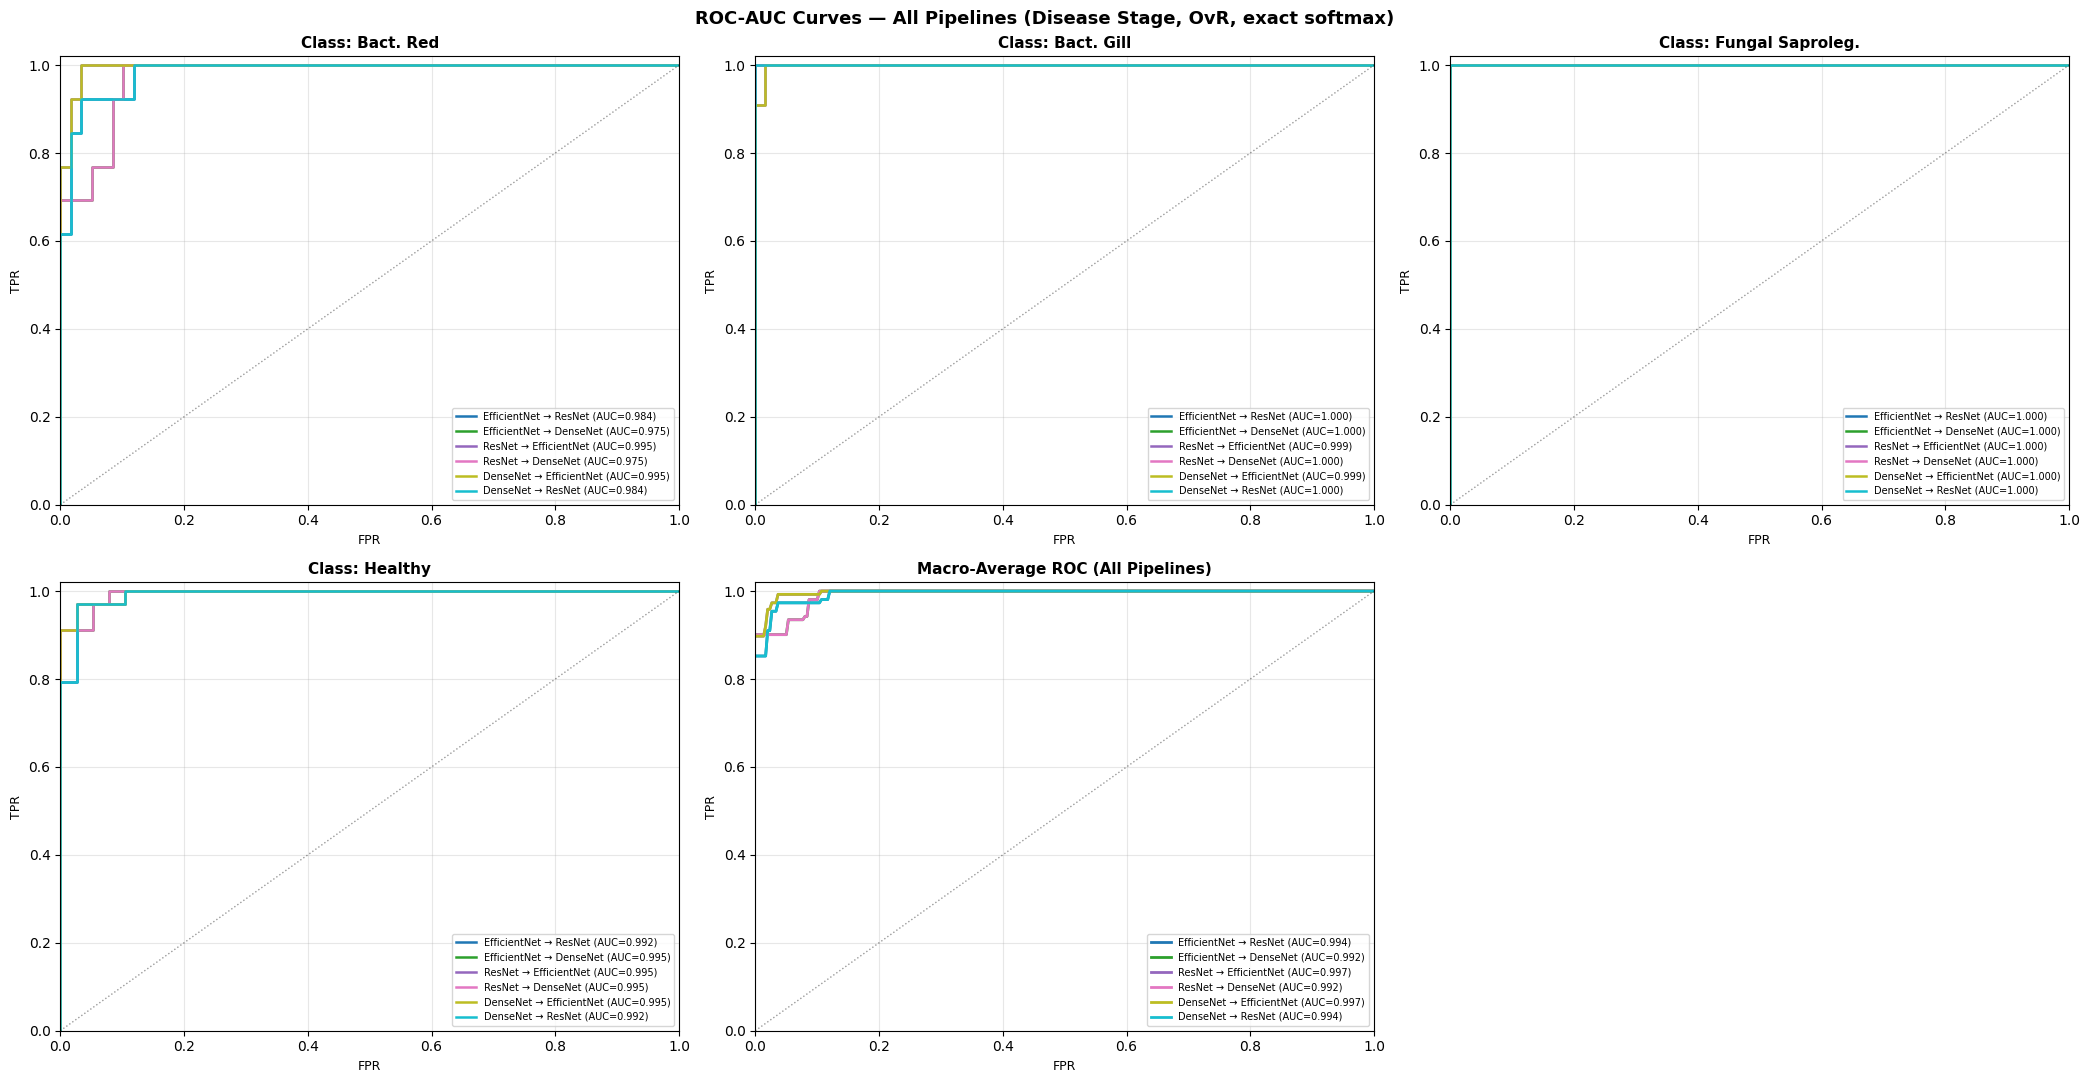

ROC-AUC (all pipelines) plotted.


In [20]:
# ── ROC-AUC: All Pipelines — Overlapping Curves ─────────────────────────────
# Uses exact softmax probability vectors stored in pipeline_outputs['disease_probs'].

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

pipeline_names = list(pipeline_outputs.keys())
n_classes      = len(disease_classes)
n_pipelines    = len(pipeline_names)
cmap           = cm.get_cmap('tab10', n_pipelines)
pip_colors     = [cmap(i) for i in range(n_pipelines)]

n_plots = n_classes + 1   # one per class + 1 macro
n_cols  = 3
n_rows  = -(-n_plots // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(7 * n_cols, 5.5 * n_rows))
axes = axes.flatten()

macro_fpr_interp = np.linspace(0, 1, 300)

for pip_idx, (pip_name, outputs) in enumerate(pipeline_outputs.items()):
    y_true      = label_binarize(outputs['disease_true'], classes=list(range(n_classes)))
    prob_matrix = outputs['disease_probs']   # exact softmax — shape (N, n_classes)

    tpr_interp_list = []

    for cls_i, cls_name in enumerate(disease_classes):
        fpr, tpr, _ = roc_curve(y_true[:, cls_i], prob_matrix[:, cls_i])
        roc_auc     = auc(fpr, tpr)

        short = cls_name.replace('Fungal diseases Saprolegniasis', 'Fungal Saproleg.') \
                        .replace('Bacterial Red disease', 'Bact. Red') \
                        .replace('Bacterial gill disease', 'Bact. Gill')

        axes[cls_i].plot(fpr, tpr, color=pip_colors[pip_idx], lw=1.8,
                         label=f'{pip_name} (AUC={roc_auc:.3f})')
        tpr_interp_list.append(np.interp(macro_fpr_interp, fpr, tpr))

    mean_tpr  = np.mean(tpr_interp_list, axis=0)
    macro_auc = auc(macro_fpr_interp, mean_tpr)
    axes[n_classes].plot(macro_fpr_interp, mean_tpr, color=pip_colors[pip_idx],
                         lw=2, label=f'{pip_name} (AUC={macro_auc:.3f})')

for cls_i, cls_name in enumerate(disease_classes):
    short = cls_name.replace('Fungal diseases Saprolegniasis', 'Fungal Saproleg.') \
                    .replace('Bacterial Red disease', 'Bact. Red') \
                    .replace('Bacterial gill disease', 'Bact. Gill')
    ax = axes[cls_i]
    ax.plot([0, 1], [0, 1], 'k:', lw=1, alpha=0.4)
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
    ax.set_xlabel('FPR', fontsize=9); ax.set_ylabel('TPR', fontsize=9)
    ax.set_title(f'Class: {short}', fontsize=11, fontweight='bold')
    ax.legend(loc='lower right', fontsize=7)
    ax.grid(alpha=0.3)

ax_macro = axes[n_classes]
ax_macro.plot([0, 1], [0, 1], 'k:', lw=1, alpha=0.4)
ax_macro.set_xlim([0, 1]); ax_macro.set_ylim([0, 1.02])
ax_macro.set_xlabel('FPR', fontsize=9); ax_macro.set_ylabel('TPR', fontsize=9)
ax_macro.set_title('Macro-Average ROC (All Pipelines)', fontsize=11, fontweight='bold')
ax_macro.legend(loc='lower right', fontsize=7)
ax_macro.grid(alpha=0.3)

for idx in range(n_classes + 1, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('ROC-AUC Curves — All Pipelines (Disease Stage, OvR, exact softmax)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/SCHOOLFILES/CPE32/CPE313/final project/results_images/roc_auc_all_pipelines.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('ROC-AUC (all pipelines) plotted.')
